## Valid vs Invalid Observation

### import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load data and Convert data

In [2]:
df = pd.read_csv("sylhet_aman_observations_2022_2024.csv")

df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

### Basic checks

In [3]:
print("Total Sentinel-2 acquisition opportunities:",
      len(df))

print("\nClear-cropland percentage:")
print(df["clear_pct"].describe())

Total Sentinel-2 acquisition opportunities: 126

Clear-cropland percentage:
count    126.000000
mean      35.751097
std       43.714883
min        0.000000
25%        0.000000
50%        0.248896
75%       89.149839
max       99.996706
Name: clear_pct, dtype: float64


### Define Validity Threshold And Classify

In [4]:
VALID_THRESHOLDS = [50, 60, 70, 80, 90]

for threshold in VALID_THRESHOLDS:

    df[f"valid_{threshold}"] = (
        df["clear_pct"] >= threshold
    )

### Calculate Overall Availability

In [5]:
overall_results = []

for threshold in VALID_THRESHOLDS:
    total = len(df)
    valid = df[f"valid_{threshold}"].sum()
    invalid = total - valid
    availability = (
                   valid / total * 100
                   )


    overall_results.append({

        "threshold": threshold,

        "total_opportunities": total,

        "valid_observations": valid,

        "invalid_observations": invalid,

        "availability_pct": availability,

    })


overall_results = pd.DataFrame(overall_results)


print("\n============================================================")
print("OVERALL OBSERVATION AVAILABILITY")
print("============================================================")

print(
    overall_results.round(2)
)



OVERALL OBSERVATION AVAILABILITY
   threshold  total_opportunities  valid_observations  invalid_observations  \
0         50                  126                  47                    79   
1         60                  126                  45                    81   
2         70                  126                  42                    84   
3         80                  126                  38                    88   
4         90                  126                  32                    94   

   availability_pct  
0             37.30  
1             35.71  
2             33.33  
3             30.16  
4             25.40  


### Combining all year by month

**This gives the overall seasonal pattern:**

June → July → August → September → October → November → December

We combine years here rather than treating each year separately.

In [6]:

seasonal_monthly_results = []

for month in sorted(df["month"].unique()):

    month_df = df[
        df["month"] == month
    ]

    for threshold in VALID_THRESHOLDS:

        total = len(month_df)

        valid = month_df[
            f"valid_{threshold}"
        ].sum()

        invalid = total - valid

        availability = (
            valid / total * 100
            if total > 0 else np.nan
        )

        seasonal_monthly_results.append({

            "month": month,

            "threshold": threshold,

            "total_opportunities": total,

            "valid_observations": valid,

            "invalid_observations": invalid,

            "availability_pct": availability

        })


seasonal_monthly_results = pd.DataFrame(
    seasonal_monthly_results
)


print("\n============================================================")
print("SEASONAL MONTHLY AVAILABILITY — ALL YEARS COMBINED")
print("============================================================")

print(
    seasonal_monthly_results.round(2)
)


SEASONAL MONTHLY AVAILABILITY — ALL YEARS COMBINED
    month  threshold  total_opportunities  valid_observations  \
0       6         50                   18                   1   
1       6         60                   18                   1   
2       6         70                   18                   1   
3       6         80                   18                   1   
4       6         90                   18                   1   
5       7         50                   18                   4   
6       7         60                   18                   4   
7       7         70                   18                   4   
8       7         80                   18                   4   
9       7         90                   18                   0   
10      8         50                   18                   2   
11      8         60                   18                   2   
12      8         70                   18                   1   
13      8         80                  

### Overall Availability vs Threshold

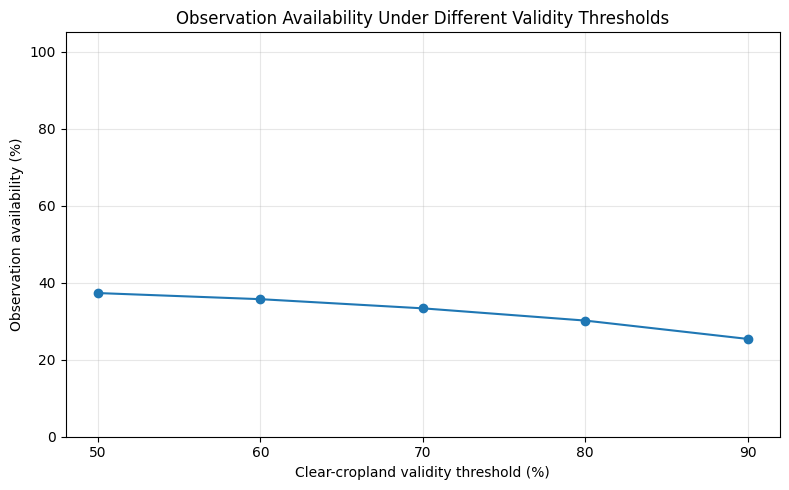

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    overall_results["threshold"],
    overall_results["availability_pct"],
    marker="o"
)

plt.xlabel(
    "Clear-cropland validity threshold (%)"
)

plt.ylabel(
    "Observation availability (%)"
)

plt.title(
    "Observation Availability Under Different Validity Thresholds"
)

plt.xticks(VALID_THRESHOLDS)

plt.ylim(0, 105)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


### Monthly Observation Availability

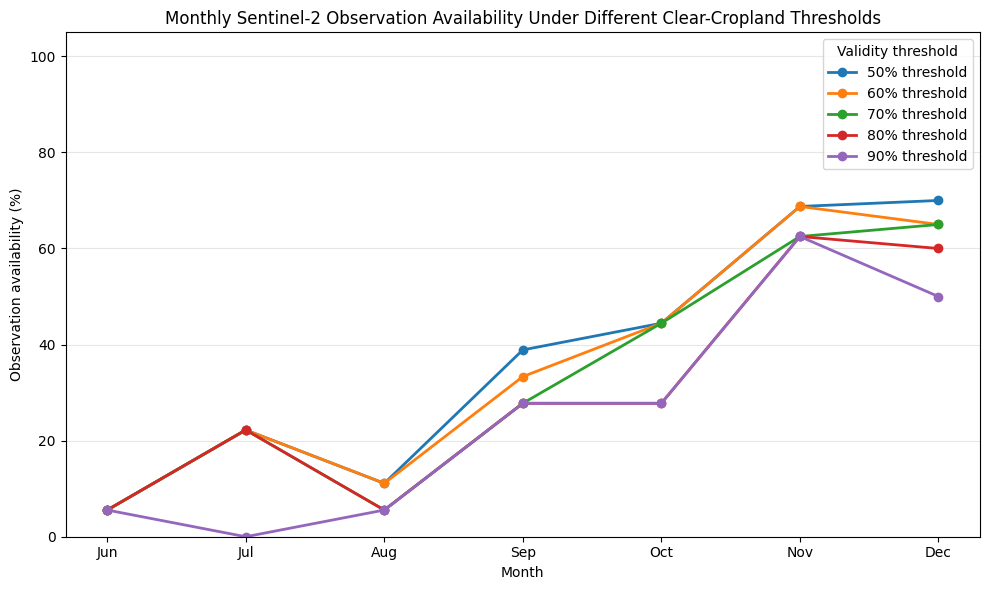

In [8]:
plt.figure(figsize=(10, 6))

for threshold in VALID_THRESHOLDS:

    plot_data = seasonal_monthly_results[
        seasonal_monthly_results["threshold"] == threshold
    ].sort_values("month")

    plt.plot(
        plot_data["month"],
        plot_data["availability_pct"],
        marker="o",
        linewidth=2,
        label=f"{threshold}% threshold"
    )


plt.xlabel("Month")

plt.ylabel("Observation availability (%)")

plt.title(
    "Monthly Sentinel-2 Observation Availability "
    "Under Different Clear-Cropland Thresholds"
)

plt.xticks(
    [6, 7, 8, 9, 10, 11, 12],
    ["Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.ylim(0, 105)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Validity threshold"
)

plt.tight_layout()

plt.show()

### Save the results

In [9]:
overall_results.to_csv(
    "overall_availability.csv",
    index=False
)

seasonal_monthly_results.to_csv(
    "seasonal_monthly_availability.csv",
    index=False
)

df.to_csv(
    "sylhet_aman_observations_classified.csv",
    index=False
)


### Final Summary

In [10]:
print("\n============================================================")
print("Summary")
print("============================================================")

print(
    "Thresholds tested:",
    VALID_THRESHOLDS
)

print(
    "Total acquisition opportunities:",
    len(df)
)

print("\nOverall availability:")

print(
    overall_results[
        [
            "threshold",
            "valid_observations",
            "invalid_observations",
            "availability_pct"
        ]
    ].round(2)
)


Summary
Thresholds tested: [50, 60, 70, 80, 90]
Total acquisition opportunities: 126

Overall availability:
   threshold  valid_observations  invalid_observations  availability_pct
0         50                  47                    79             37.30
1         60                  45                    81             35.71
2         70                  42                    84             33.33
3         80                  38                    88             30.16
4         90                  32                    94             25.40


In [11]:
print("Total acquisitions:", len(df))
print("NDVI median null:", df["ndvi_median"].isna().sum())   # rename column if yours differs
print("NDVI median available:", df["ndvi_median"].notna().sum())
print()
print("clear_pct == 0:", (df["clear_pct"] == 0).sum())
print("clear_pct > 0 but < 50:", ((df["clear_pct"] > 0) & (df["clear_pct"] < 50)).sum())
print()
# Cross-check: does null NDVI line up with clear_pct == 0?
print(df.loc[df["ndvi_median"].isna(), "clear_pct"].describe())

Total acquisitions: 126
NDVI median null: 58
NDVI median available: 68

clear_pct == 0: 58
clear_pct > 0 but < 50: 21

count    58.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: clear_pct, dtype: float64
